可选站点：
 1: (0.26535969683863625, 1.988376506866485)  (凸包点)
 2: (0.797919769236275, 2.327908863610302)  (内部点)
 3: (0.9274584338014791, 0.9671637683346401)  (凸包点)
 4: (1.0100142940972912, 2.779736031100921)  (内部点)
 5: (1.634024937619284, 3.794554417576478)  (内部点)
 6: (1.7113864819809699, 7.291267979503492)  (凸包点)
 7: (2.1863797480360336, 5.053552881033624)  (内部点)
 8: (2.204406220406967, 5.892656838759088)  (内部点)
 9: (2.2789827565154686, 2.8938796360210715)  (内部点)
10: (2.669778220491134, 9.36654587712494)  (凸包点)
11: (2.7502931836911926, 2.2321073814882277)  (内部点)
12: (3.4025051651799187, 1.5547949981178155)  (内部点)
13: (3.701809671168826, 2.095070307714877)  (内部点)
14: (3.785343772083535, 5.52040631273227)  (内部点)
15: (4.2192181968527045, 0.29797219438070344)  (凸包点)
16: (5.362280914547007, 9.731157639793706)  (凸包点)
17: (6.356844442644002, 3.6483217897008426)  (内部点)
18: (6.394267984578837, 0.25010755222666936)  (内部点)
19: (6.480353852465935, 6.091310056669882)  (内部点)
20: (6.498844377795232, 5.4

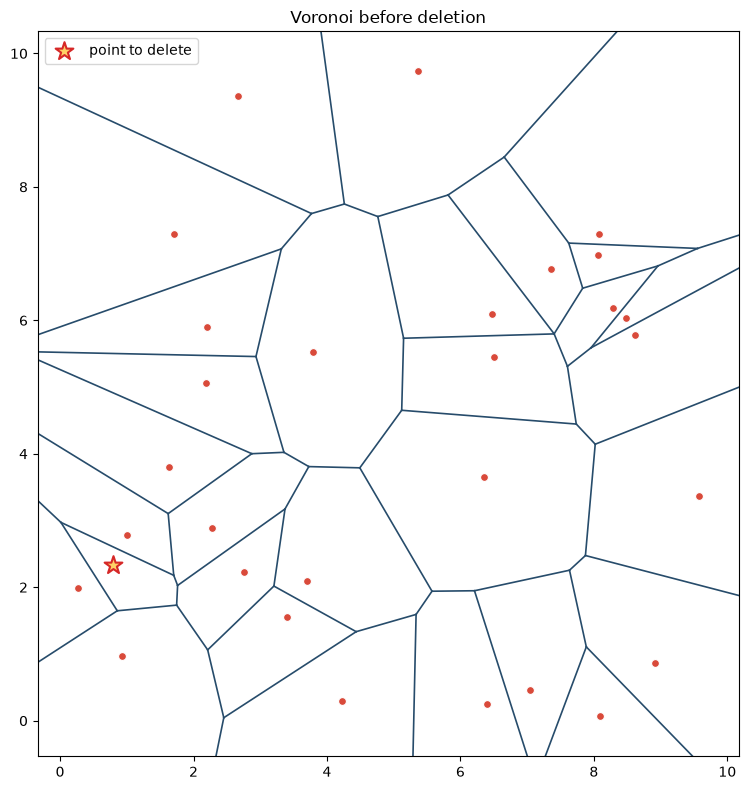

删除后：
  点数： 29
  三角形数： 46


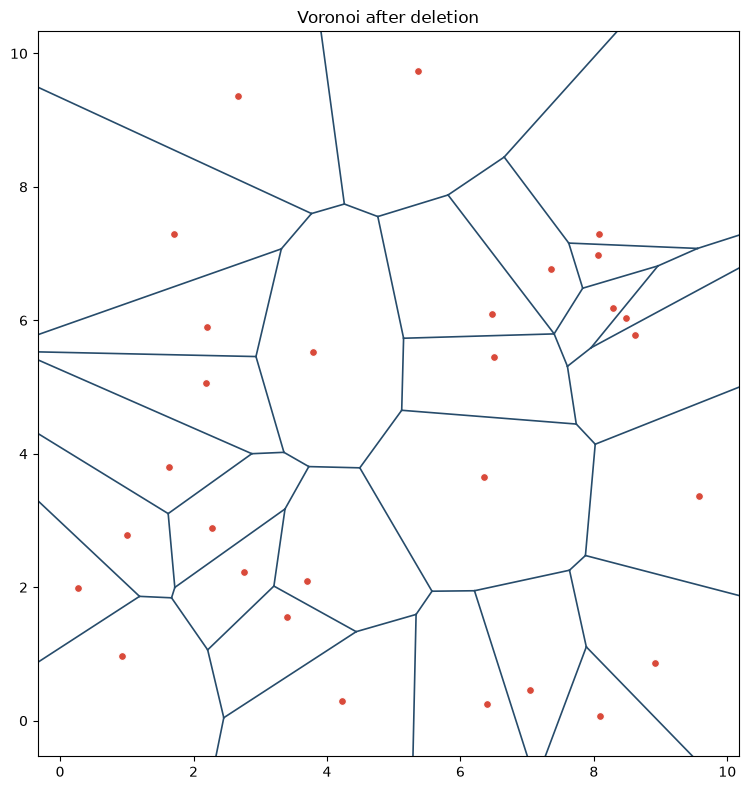

In [1]:
from collections import Counter, defaultdict
import math
import random

EPS = 1e-10


# ---------------------------------------------------------------------------
# 基础结构
# ---------------------------------------------------------------------------


class Edge:
    """无向边，用作空腔边界统计。"""

    __slots__ = ("a", "b")

    def __init__(self, a, b):
        self.a, self.b = (a, b) if a <= b else (b, a)

    def __eq__(self, other):
        return (
                isinstance(other, Edge)
                and self.a == other.a
                and self.b == other.b
        )

    def __hash__(self):
        return hash((self.a, self.b))


class Triangle:
    __slots__ = ("a", "b", "c", "cx", "cy", "r2")

    def __init__(self, a, b, c):
        self.a = a
        self.b = b
        self.c = c
        self.cx, self.cy, self.r2 = circumcircle(a, b, c)

    def contains_in_circumcircle(self, p, eps=1e-10):
        """点 p 是否位于外接圆内或圆上。"""
        dx = p[0] - self.cx
        dy = p[1] - self.cy
        dist2 = dx * dx + dy * dy
        tolerance = eps * max(1.0, self.r2)
        return dist2 <= self.r2 + tolerance

    def has_vertex(self, p):
        return p == self.a or p == self.b or p == self.c


def circumcircle(a, b, c):
    """返回三角形的外接圆圆心和半径平方。"""
    ax, ay = a
    bx, by = b
    cx, cy = c

    d = 2.0 * (
            ax * (by - cy)
            + bx * (cy - ay)
            + cx * (ay - by)
    )

    if abs(d) < 1e-12:
        raise ValueError("三点共线，无法构成三角形")

    ux = (
                 (ax * ax + ay * ay) * (by - cy)
                 + (bx * bx + by * by) * (cy - ay)
                 + (cx * cx + cy * cy) * (ay - by)
         ) / d

    uy = (
                 (ax * ax + ay * ay) * (cx - bx)
                 + (bx * bx + by * by) * (ax - cx)
                 + (cx * cx + cy * cy) * (bx - ax)
         ) / d

    r2 = (ux - ax) ** 2 + (uy - ay) ** 2
    return ux, uy, r2


# ---------------------------------------------------------------------------
# Bowyer-Watson 建网
# ---------------------------------------------------------------------------


def bowyer_watson(points):
    """
    输入：
        points: [(x, y), ...]

    输出：
        triangles: [(p1, p2, p3), ...]
    """
    pts = sorted(set((float(x), float(y)) for x, y in points))

    if len(pts) < 3:
        return []

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    dx = max_x - min_x
    dy = max_y - min_y
    d = max(dx, dy, 1.0)

    mid_x = (min_x + max_x) / 2.0
    mid_y = (min_y + max_y) / 2.0

    s1 = (mid_x - 30.0 * d, min_y - 30.0 * d)
    s2 = (mid_x + 30.0 * d, min_y - 30.0 * d)
    s3 = (mid_x, max_y + 30.0 * d)

    super_triangle = Triangle(s1, s2, s3)
    triangles = [super_triangle]

    for p in pts:
        bad_triangles = [
            tri for tri in triangles
            if tri.contains_in_circumcircle(p)
        ]

        if not bad_triangles:
            continue

        edge_count = Counter()

        for tri in bad_triangles:
            edge_count[Edge(tri.a, tri.b)] += 1
            edge_count[Edge(tri.b, tri.c)] += 1
            edge_count[Edge(tri.c, tri.a)] += 1

        boundary_edges = [
            edge for edge, count in edge_count.items()
            if count == 1
        ]

        triangles = [
            tri for tri in triangles
            if tri not in bad_triangles
        ]

        for edge in boundary_edges:
            try:
                triangles.append(Triangle(edge.a, edge.b, p))
            except ValueError:
                pass

    super_vertices = {s1, s2, s3}

    result = []
    for tri in triangles:
        if (
                tri.a not in super_vertices
                and tri.b not in super_vertices
                and tri.c not in super_vertices
        ):
            result.append((tri.a, tri.b, tri.c))

    return result


# ---------------------------------------------------------------------------
# 几何谓词和洞回填工具
# ---------------------------------------------------------------------------


def orient(a, b, c):
    """叉积 (b-a) x (c-a)。"""
    return (
            (b[0] - a[0]) * (c[1] - a[1])
            - (b[1] - a[1]) * (c[0] - a[0])
    )


def in_circle(a, b, c, d):
    """四点圆内测试；a,b,c 逆时针时 > 0 表示 d 在圆内。"""
    adx = a[0] - d[0]
    ady = a[1] - d[1]
    bdx = b[0] - d[0]
    bdy = b[1] - d[1]
    cdx = c[0] - d[0]
    cdy = c[1] - d[1]

    return (
            (adx * adx + ady * ady) * (bdx * cdy - cdx * bdy)
            - (bdx * bdx + bdy * bdy) * (adx * cdy - cdx * ady)
            + (cdx * cdx + cdy * cdy) * (adx * bdy - bdx * ady)
    )


def triangle_ccw(tri):
    a, b, c = tri
    o = orient(a, b, c)
    if abs(o) <= EPS:
        return None
    return (a, b, c) if o > 0 else (a, c, b)


def triangle_edges(tri):
    a, b, c = tri
    yield (a, b)
    yield (b, c)
    yield (c, a)


def normalized_edge(u, v):
    return (u, v) if u <= v else (v, u)


def opposite_vertex(tri, u, v):
    for x in tri:
        if x != u and x != v:
            return x
    raise ValueError(f"三角形 {tri} 不包含边 ({u}, {v})")


def polygon_signed_area(poly):
    s = 0.0
    n = len(poly)
    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % n]
        s += x1 * y2 - x2 * y1
    return 0.5 * s


def point_in_triangle(p, a, b, c):
    return (
            orient(a, b, p) >= -EPS
            and orient(b, c, p) >= -EPS
            and orient(c, a, p) >= -EPS
    )


def remove_collinear(poly):
    if len(poly) <= 3:
        return poly

    result = list(poly)
    changed = True

    while changed and len(result) > 3:
        changed = False
        n = len(result)

        for i in range(n):
            a = result[(i - 1) % n]
            b = result[i]
            c = result[(i + 1) % n]

            if abs(orient(a, b, c)) <= EPS:
                result.pop(i)
                changed = True
                break

    return result


def ear_clip_polygon(poly):
    """对简单多边形做耳切，得到初始三角化。"""
    poly = remove_collinear(list(poly))

    if len(poly) < 3:
        return []

    if polygon_signed_area(poly) < 0:
        poly.reverse()

    idx = list(range(len(poly)))
    result = []
    guard = 0

    while len(idx) > 3 and guard < len(poly) * len(poly) * 10:
        guard += 1
        ear_found = False

        for i in range(len(idx)):
            ia = idx[(i - 1) % len(idx)]
            ib = idx[i]
            ic = idx[(i + 1) % len(idx)]

            a, b, c = poly[ia], poly[ib], poly[ic]

            if orient(a, b, c) <= EPS:
                continue

            contains_other = False
            for j in idx:
                if j in (ia, ib, ic):
                    continue
                if point_in_triangle(poly[j], a, b, c):
                    contains_other = True
                    break

            if not contains_other:
                result.append((poly[ia], poly[ib], poly[ic]))
                idx.pop(i)
                ear_found = True
                break

        if not ear_found:
            # 退化输入兜底：先去掉共线点，再裁凸顶点。
            removed = False
            for i in range(len(idx)):
                ia = idx[(i - 1) % len(idx)]
                ib = idx[i]
                ic = idx[(i + 1) % len(idx)]
                if abs(orient(poly[ia], poly[ib], poly[ic])) <= EPS:
                    idx.pop(i)
                    removed = True
                    break

            if removed:
                continue

            for i in range(len(idx)):
                ia = idx[(i - 1) % len(idx)]
                ib = idx[i]
                ic = idx[(i + 1) % len(idx)]
                if orient(poly[ia], poly[ib], poly[ic]) > EPS:
                    result.append((poly[ia], poly[ib], poly[ic]))
                    idx.pop(i)
                    ear_found = True
                    break

            if not ear_found:
                raise RuntimeError("耳切失败：多边形可能不是简单多边形")

    if len(idx) == 3:
        result.append((poly[idx[0]], poly[idx[1]], poly[idx[2]]))

    return result


def constrained_delaunay_polygon(poly):
    """对多边形洞做约束 Delaunay 三角化。"""
    tris = [
        t for t in ear_clip_polygon(poly)
        if triangle_ccw(t) is not None
    ]

    if not tris:
        return []

    max_iter = max(100, len(tris) * len(tris) * 10)

    for _ in range(max_iter):
        edge_to_tris = defaultdict(list)

        for ti, tri in enumerate(tris):
            for u, v in triangle_edges(tri):
                edge_to_tris[normalized_edge(u, v)].append(ti)

        flipped = False

        for edge, triangle_indices in list(edge_to_tris.items()):
            if len(triangle_indices) != 2:
                continue

            t1, t2 = triangle_indices
            u, v = edge
            c = opposite_vertex(tris[t1], u, v)
            d = opposite_vertex(tris[t2], u, v)

            # c,d 在 uv 两侧，且 u,v 在 cd 两侧，四边形才是凸的。
            if orient(u, v, c) * orient(u, v, d) >= 0:
                continue
            if orient(c, d, u) * orient(c, d, v) >= 0:
                continue

            ccw_t1 = triangle_ccw(tris[t1])
            if ccw_t1 is None:
                continue

            a, b, e = ccw_t1
            if in_circle(a, b, e, d) <= EPS:
                continue

            new1 = triangle_ccw((c, d, u))
            new2 = triangle_ccw((c, d, v))

            if new1 is None or new2 is None:
                continue

            tris[t1] = new1
            tris[t2] = new2
            flipped = True
            break

        if not flipped:
            break

    result = []
    seen = set()

    for tri in tris:
        normalized = triangle_ccw(tri)
        if normalized is None:
            continue

        key = frozenset(normalized)
        if key in seen:
            continue

        seen.add(key)
        result.append(normalized)

    return result


def is_hull_vertex(triangles, p):
    """判断 p 是否是当前 Delaunay 凸包顶点。"""
    incident = [tri for tri in triangles if p in tri]

    if not incident:
        return False

    edge_count = Counter()

    for tri in incident:
        a, b, c = tri
        edge_count[Edge(a, b)] += 1
        edge_count[Edge(b, c)] += 1
        edge_count[Edge(c, a)] += 1

    for edge, count in edge_count.items():
        if (edge.a == p or edge.b == p) and count == 1:
            return True

    return False


# ---------------------------------------------------------------------------
# 动态删点
# ---------------------------------------------------------------------------


def delete_point(points, triangles, p):
    """
    从当前点集和 Delaunay 三角网中删除点 p。

    返回新的：
        new_points, new_triangles

    说明：
    - 内部点：只删除 p 周围的三角形扇，回填星形洞；
    - 凸包点：凸包会改变，这里回退到 Bowyer-Watson 全局重建。
    """
    p = (float(p[0]), float(p[1]))

    if p not in points:
        return list(points), list(triangles)

    incident = [tri for tri in triangles if p in tri]

    if not incident:
        return [q for q in points if q != p], []

    # 凸包点删除会改变凸包，局部洞边界不只是邻居环。
    if is_hull_vertex(triangles, p):
        new_points = [q for q in points if q != p]
        return new_points, bowyer_watson(new_points)

    neighbors = set()

    for tri in incident:
        neighbors.update(tri)

    neighbors.discard(p)

    # 删除 p 的三角形扇。
    remaining_triangles = [
        tri for tri in triangles
        if p not in tri
    ]

    # 按围绕 p 的极角排序，得到洞的边界环。
    px, py = p
    ring = sorted(
        neighbors,
        key=lambda q: math.atan2(q[1] - py, q[0] - px),
    )

    if len(ring) >= 3:
        if polygon_signed_area(ring) < 0:
            ring.reverse()

        new_triangles = constrained_delaunay_polygon(ring)

        for tri in new_triangles:
            normalized = triangle_ccw(tri)
            if normalized is not None:
                remaining_triangles.append(normalized)

    return [q for q in points if q != p], remaining_triangles


class DynamicVoronoi:
    """维护一个可动态删除站点的 Delaunay / Voronoi 结构。"""

    def __init__(self, points):
        self.points = sorted(set((float(x), float(y)) for x, y in points))
        self.triangles = bowyer_watson(self.points)

    def delete_point(self, p):
        self.points, self.triangles = delete_point(
            self.points,
            self.triangles,
            p,
        )

    def rebuild(self):
        self.triangles = bowyer_watson(self.points)

    def hull_points(self):
        return [
            p for p in self.points
            if is_hull_vertex(self.triangles, p)
        ]


# ---------------------------------------------------------------------------
# Delaunay -> Voronoi
# ---------------------------------------------------------------------------


def voronoi_from_delaunay(triangles):
    """
    根据 Delaunay 三角网生成 Voronoi 图。

    返回：
        centers:      Voronoi 顶点
        finite_edges: 有限的 Voronoi 边
        rays:         无穷 Voronoi 射线
    """
    centers = []
    edge_map = defaultdict(list)

    for i, (a, b, c) in enumerate(triangles):
        ux, uy, _ = circumcircle(a, b, c)
        centers.append((ux, uy))

        for edge in ((a, b), (b, c), (c, a)):
            edge_map[Edge(*edge)].append((i, (a, b, c)))

    finite_edges = []
    rays = []

    for edge, data in edge_map.items():
        if len(data) == 2:
            i, _ = data[0]
            j, _ = data[1]
            finite_edges.append((centers[i], centers[j]))

        elif len(data) == 1:
            i, tri = data[0]
            cx, cy = centers[i]

            a, b = edge.a, edge.b

            # 找到真正不在这条边上的第三点
            third = next(v for v in tri if v != a and v != b)

            dx = b[0] - a[0]
            dy = b[1] - a[1]

            # 垂直于边 ab 的两个方向
            n1 = (dy, -dx)
            n2 = (-dy, dx)

            # 边中点
            mid = ((a[0] + b[0]) * 0.5, (a[1] + b[1]) * 0.5)

            # 指向远离第三点的方向
            away = (mid[0] - third[0], mid[1] - third[1])

            if n1[0] * away[0] + n1[1] * away[1] > 0:
                nx, ny = n1
            else:
                nx, ny = n2

            length = math.hypot(nx, ny)
            if length > 1e-12:
                nx /= length
                ny /= length
                rays.append(((cx, cy), (nx, ny)))

    return centers, finite_edges, rays


# ---------------------------------------------------------------------------
# 绘图
# ---------------------------------------------------------------------------

def plot_voronoi(points, triangles, title, save_path=None, show=True , highlight_point=None):
    import matplotlib.pyplot as plt

    _, finite_edges, rays = voronoi_from_delaunay(triangles)

    plt.figure(figsize=(8, 8))

    # 有限 Voronoi 边
    for p, q in finite_edges:
        plt.plot(
            [p[0], q[0]],
            [p[1], q[1]],
            color="#274c6b",
            linewidth=1.2,
        )

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    if xs:
        width = max(xs) - min(xs)
        height = max(ys) - min(ys)
        ray_length = 2.0 * max(width, height, 1.0)

        # 无限 Voronoi 射线
        for start, direction in rays:
            x0, y0 = start
            dx, dy = direction
            plt.plot(
                [x0, x0 + dx * ray_length],
                [y0, y0 + dy * ray_length],
                color="#274c6b",
                linewidth=1.2,
            )

        # 站点
        plt.scatter(
            xs,
            ys,
            s=32,
            c="#d94a3a",
            edgecolors="white",
            linewidths=0.8,
            zorder=5,
        )

        if highlight_point is not None and highlight_point in points:
            hx, hy = highlight_point
            plt.scatter(
                [hx],
                [hy],
                s=180,
                marker="*",
                c="#ffd166",
                edgecolors="#d62828",
                linewidths=1.5,
                zorder=6,
                label="point to delete",
            )
            plt.legend(loc = 'best')

        padding = 0.6
        plt.xlim(min(xs) - padding, max(xs) + padding)
        plt.ylim(min(ys) - padding, max(ys) + padding)

    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
            facecolor="white",
        )

    if show:
        plt.show()

    plt.close()


# ---------------------------------------------------------------------------
# 演示
# ---------------------------------------------------------------------------


def main():
    random.seed(42)

    points = [
        (random.random() * 10, random.random() * 10) for i in range(30)
    ]

    model = DynamicVoronoi(points)

    hull_points = set(model.hull_points())

    print("可选站点：")
    for idx, p in enumerate(model.points, start=1):
        kind = "凸包点" if p in hull_points else "内部点"
        print(f"{idx:2d}: {p}  ({kind})")

    raw = input("请输入要删除的站点编号，直接回车默认删除第 1 个：").strip()

    if raw == "":
        index = 1
    else:
        index = int(raw)

    if not (1 <= index <= len(model.points)):
        raise ValueError(f"编号必须在 1 到 {len(model.points)} 之间")

    deleted = model.points[index - 1]

    print("即将删除：", deleted)

    print("删除前：")
    print("  点数：", len(model.points))
    print("  三角形数：", len(model.triangles))
    print("  删除点：", deleted)
    print("  是否为凸包点：", deleted in hull_points)

    plot_voronoi(
        model.points,
        model.triangles,
        "Voronoi before deletion",
        save_path="voronoi_before_delete.png",
        highlight_point= deleted,
        show=True,
    )

    model.delete_point(deleted)

    print("删除后：")
    print("  点数：", len(model.points))
    print("  三角形数：", len(model.triangles))

    plot_voronoi(
        model.points,
        model.triangles,
        "Voronoi after deletion",
        save_path="voronoi_after_delete.png",
        show=True,
    )

    # 如果你的环境支持 Matplotlib 窗口，可以改成 True。
    # plot_voronoi(model.points, model.triangles, "Voronoi after deletion", show=True)

